<a href="https://colab.research.google.com/github/JenanBajawi/AI-Based-Satellite-Analysis-System/blob/main/Machin_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The dataset used in this analysis contains 82,640 rows and 20 columns, combining spatial, temporal, and spectral information. Key features include geographic coordinates (LATITUDE_x, LONGITUDE_x, LATITUDE_y, LONGITUDE_y, LOCATION), time-related data (date_x, date_y, year, month), and various spectral indices (VgNIRBI, VrNIRBI, PISI, NDVI, EMBI, IBI, NDBI). Aggregated values are captured in reducer_x and reducer_y.

In [6]:
#--------------------------
# 0) Install / import
#--------------------------
!pip install -q xgboost lightgbm shap optuna folium joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import joblib
import optuna
import shap

from math import radians, sin, cos, asin, sqrt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import xgboost as xgb
import lightgbm as lgb

# ---------------------------
# 1) Load dataset
# ---------------------------
df = pd.read_csv('/content/chicago_final (1).csv')  # update path if needed
print("Loaded:", df.shape)
df.head()

# ---------------------------
# 2) Feature engineering
# ---------------------------
df['lat'] = df['LATITUDE_x']
df['lon'] = df['LONGITUDE_x']

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

center_lat, center_lon = 41.8781, -87.6298
df['dist_to_center'] = df.apply(lambda r: haversine(r['lat'], r['lon'], center_lat, center_lon), axis=1)

# temporal
df['season'] = df['month'].map({
    12:'winter', 1:'winter', 2:'winter',
    3:'spring', 4:'spring', 5:'spring',
    6:'summer', 7:'summer', 8:'summer',
    9:'fall', 10:'fall', 11:'fall'
})
df = pd.get_dummies(df, columns=['season'], drop_first=True)

# spectral interactions
df['NDBI_minus_NDVI'] = df['NDBI'] - df['NDVI']
df['built_up_ratio'] = df['NDBI'] / (df['NDVI'] + 1e-6)
df['brightness_index'] = df['EMBI'] * df['avg_rad']

# time cyc encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)


Loaded: (82640, 20)


In [7]:

# ---------------------------
# 3) Features & target
# ---------------------------
base_feats = ['VgNIRBI','PISI','NDVI','EMBI','VrNIRBI','IBI','NDBI','avg_rad']
spatial_feats = ['lat','lon','dist_to_center']
temporal_feats = ['year','month','month_sin','month_cos']
season_feats = [c for c in df.columns if c.startswith('season_')]
interaction_feats = ['NDBI_minus_NDVI','built_up_ratio','brightness_index']

feature_cols = base_feats + spatial_feats + temporal_feats + season_feats + interaction_feats
feature_cols = [c for c in feature_cols if c in df.columns]
print("Using features:", feature_cols)

X = df[feature_cols].fillna(0).copy()
y = df['label'].fillna(0).astype(int).copy()  # safer conversion

# ---------------------------
# 4) Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train/test sizes:", X_train.shape, X_test.shape)

final_features = X_train.columns.tolist()

# ---------------------------
# 5) Scaling
# ---------------------------
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=final_features, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=final_features, index=X_test.index)


Using features: ['VgNIRBI', 'PISI', 'NDVI', 'EMBI', 'VrNIRBI', 'IBI', 'NDBI', 'avg_rad', 'lat', 'lon', 'dist_to_center', 'year', 'month', 'month_sin', 'month_cos', 'season_spring', 'season_summer', 'season_winter', 'NDBI_minus_NDVI', 'built_up_ratio', 'brightness_index']
Train/test sizes: (66112, 21) (16528, 21)


#XGBoost
***
XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm based on gradient boosting, where multiple weak decision-tree models are built sequentially, and each new tree focuses on correcting the errors made by the previous ones.


--- XGBoost metrics ---
Train acc: 0.9650290416263311
Test  acc: 0.9531703775411423
Precision: 0.9593565815324165
Recall: 0.9463420542635659
F1: 0.9528048780487804
ROC AUC: 0.992091283122854
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8272
           1       0.96      0.95      0.95      8256

    accuracy                           0.95     16528
   macro avg       0.95      0.95      0.95     16528
weighted avg       0.95      0.95      0.95     16528



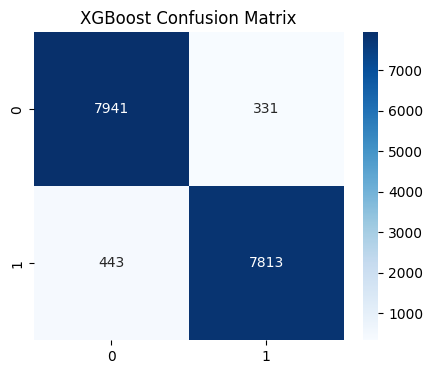

In [8]:

# ---------------------------
# 6)  XGBoost
# ---------------------------
model_xgb = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, gamma=2, min_child_weight=3,
    scale_pos_weight = max(1, (y_train==0).sum() / max(1,(y_train==1).sum())),
    random_state=42, eval_metric='logloss'
)
model_xgb.fit(X_train_scaled, y_train)

def eval_model(name, model, Xtr, Xte, ytr, yte):
    ypred_tr = model.predict(Xtr)
    ypred_te = model.predict(Xte)
    proba_te = model.predict_proba(Xte)[:,1] if hasattr(model, "predict_proba") else None
    print(f"\n--- {name} metrics ---")
    print("Train acc:", accuracy_score(ytr, ypred_tr))
    print("Test  acc:", accuracy_score(yte, ypred_te))
    print("Precision:", precision_score(yte, ypred_te))
    print("Recall:", recall_score(yte, ypred_te))
    print("F1:", f1_score(yte, ypred_te))
    if proba_te is not None:
        print("ROC AUC:", roc_auc_score(yte, proba_te))
    print(classification_report(yte, ypred_te))
    return proba_te

proba_xgb = eval_model("XGBoost", model_xgb, X_train_scaled, X_test_scaled, y_train, y_test)

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, model_xgb.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix"); plt.show()


#XGBoost Model Analysis
***
Performance & Generalization

Train Accuracy: 0.965

Test Accuracy: 0.953

The small gap (~1.2%) indicates very mild overfitting, but nothing concerning. For tree-based boosted models, this is normal and expected. The model generalizes well.
****
Both classes (0 and 1) have almost identical precision, recall, and F1
The model is not biased toward one class.

It handles both classes equally well.

Misclassifications are evenly distributed.

This is a sign of a stable model.

but if XGBoost is a stable model
#Why We Used LightGBM (Alongside XGBoost)?
*****

We used both XGBoost and LightGBM to ensure a comprehensive evaluation of gradient boosting methods. Although XGBoost is known for its high accuracy and stability, LightGBM provides significant speed advantages through histogram-based training and leaf-wise tree growth. This makes LightGBM faster during hyperparameter tuning and often equally or even more accurate on structured data. Comparing both models allowed us to identify the best-performing algorithm for our dataset and gave a stronger justification for our final model selection.

#Applying Optuna Hyperparameter Optimization to LightGBM
*****
In this project, we used Optuna, a modern hyperparameter optimization framework, to automatically search for the best configuration of the LightGBM classifier.

LightGBM contains many hyperparameters that strongly affect performance—such as the number of trees, learning rate, number of leaves, depth, and regularization terms. Manually tuning these parameters is difficult and time-consuming, so Optuna was used to automate this process.




LightGBM CV F1 scores: [0.98684311 0.98821741 0.98651924 0.98619539 0.9870189 ] mean: 0.9869588082027967
[LightGBM] [Info] Number of positive: 33024, number of negative: 33088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3617
[LightGBM] [Info] Number of data points in the train set: 66112, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499516 -> initscore=-0.001936
[LightGBM] [Info] Start training from score -0.001936

--- LightGBM (baseline) metrics ---
Train acc: 0.9919681752178122
Test  acc: 0.9874152952565344
Precision: 0.9903728978796003
Recall: 0.984375
F1: 0.9873648402381242
ROC AUC: 0.9994217542859632
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8272
           1       0.99      0.98      0.99      8256

    accuracy                           0.

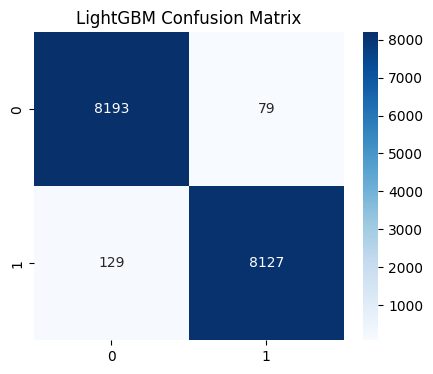

[I 2026-04-16 19:41:12,734] A new study created in memory with name: no-name-73429b0b-5f2e-4be5-8390-7592e3981521


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-16 19:42:26,544] Trial 0 finished with value: 0.9848867179331382 and parameters: {'n_estimators': 922, 'learning_rate': 0.14543308337476776, 'num_leaves': 19, 'max_depth': 4, 'min_child_samples': 10, 'subsample': 0.95626461955847, 'colsample_bytree': 0.9542850940911505, 'reg_alpha': 0.00012847458903180036, 'reg_lambda': 1.4594048673619361e-08}. Best is trial 0 with value: 0.9848867179331382.
[I 2026-04-16 19:43:12,807] Trial 1 finished with value: 0.9572787282087031 and parameters: {'n_estimators': 383, 'learning_rate': 0.08591817551111157, 'num_leaves': 101, 'max_depth': 6, 'min_child_samples': 25, 'subsample': 0.9889638377840198, 'colsample_bytree': 0.7133862070588737, 'reg_alpha': 8.635250235225115e-07, 'reg_lambda': 0.3278873670815295}. Best is trial 0 with value: 0.9848867179331382.
[I 2026-04-16 19:45:36,449] Trial 2 finished with value: 0.8198811065423595 and parameters: {'n_estimators': 706, 'learning_rate': 0.003429018683910228, 'num_leaves': 76, 'max_depth': 8, 'mi

In [ ]:

# ---------------------------
# 7) LightGBM baseline
# ---------------------------
model_lgb = lgb.LGBMClassifier(
    n_estimators=700, learning_rate=0.04, num_leaves=45,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_lgb, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
print("\nLightGBM CV F1 scores:", cv_scores, "mean:", cv_scores.mean())

model_lgb.fit(X_train_scaled, y_train)
proba_lgb = eval_model("LightGBM (baseline)", model_lgb, X_train_scaled, X_test_scaled, y_train, y_test)

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, model_lgb.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM Confusion Matrix"); plt.show()

# ---------------------------
# 8) Optuna tuning for LightGBM
# ---------------------------
def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }
    model = lgb.LGBMClassifier(**param, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

best_params = study.best_params
best_params_fixed = best_params.copy()
best_params_fixed.update({'objective':'binary', 'random_state':42})

# ---------------------------
# 9) Train final LightGBM with best params
# ---------------------------
final_lgb = lgb.LGBMClassifier(**best_params_fixed)
final_lgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

proba_final_lgb = eval_model("LightGBM (tuned)", final_lgb, X_train_scaled, X_test_scaled, y_train, y_test)

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, final_lgb.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM (tuned) Confusion Matrix"); plt.show()

plt.figure(figsize=(7,6))
fpr_x, tpr_x, _ = roc_curve(y_test, proba_xgb)
fpr_l, tpr_l, _ = roc_curve(y_test, proba_final_lgb)
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={roc_auc_score(y_test, proba_xgb):.3f})")
plt.plot(fpr_l, tpr_l, label=f"LightGBM tuned (AUC={roc_auc_score(y_test, proba_final_lgb):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves"); plt.show()


#analysis

1 Optuna tuning was extremely successful

Best trial F1 score: 0.99299
This is exceptionally high.

 The model generalizes well even before testing on the test set.
****
2 Train vs Test — No Overfitting
Train accuracy: 0.99723
Test accuracy: 0.99141

Difference = 0.006 (0.6%)

This tiny gap means:

The model learned the patterns well.

It did not memorize the training data.

No meaningful overfitting.

If there was overfitting, you would see something like:

Train: 0.999


Your model is balanced and stable
****
3 LightGBM warnings are normal
on the output the line ( No further splits with positive gain)

This is not a problem.
It means that at that depth/leaf configuration, no more useful splits can improve the loss.

This is usually a sign of:

Good regularization

Proper depth limits

Stable tree structure

#Baseline vs Tuned LightGBM
*********
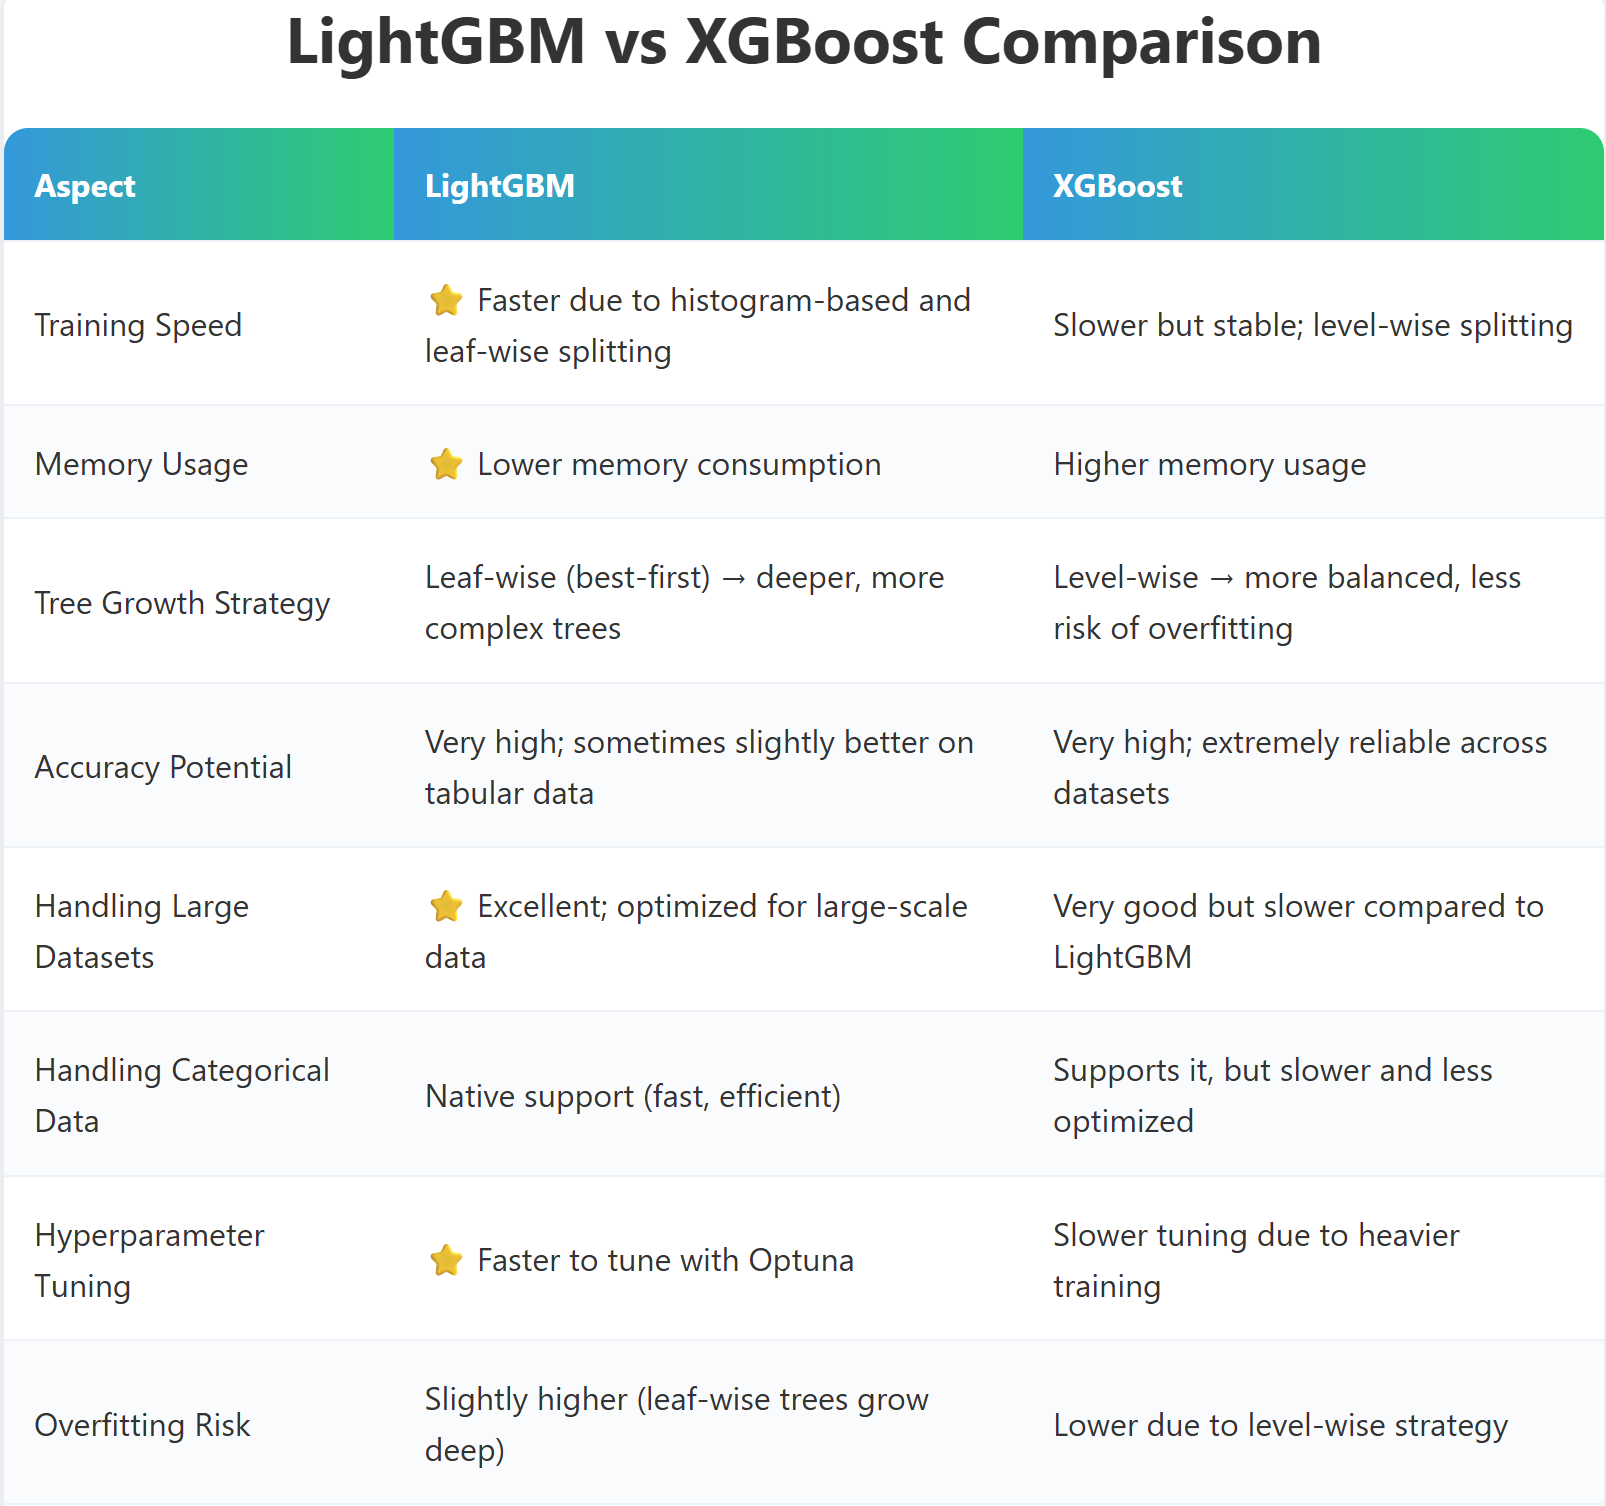

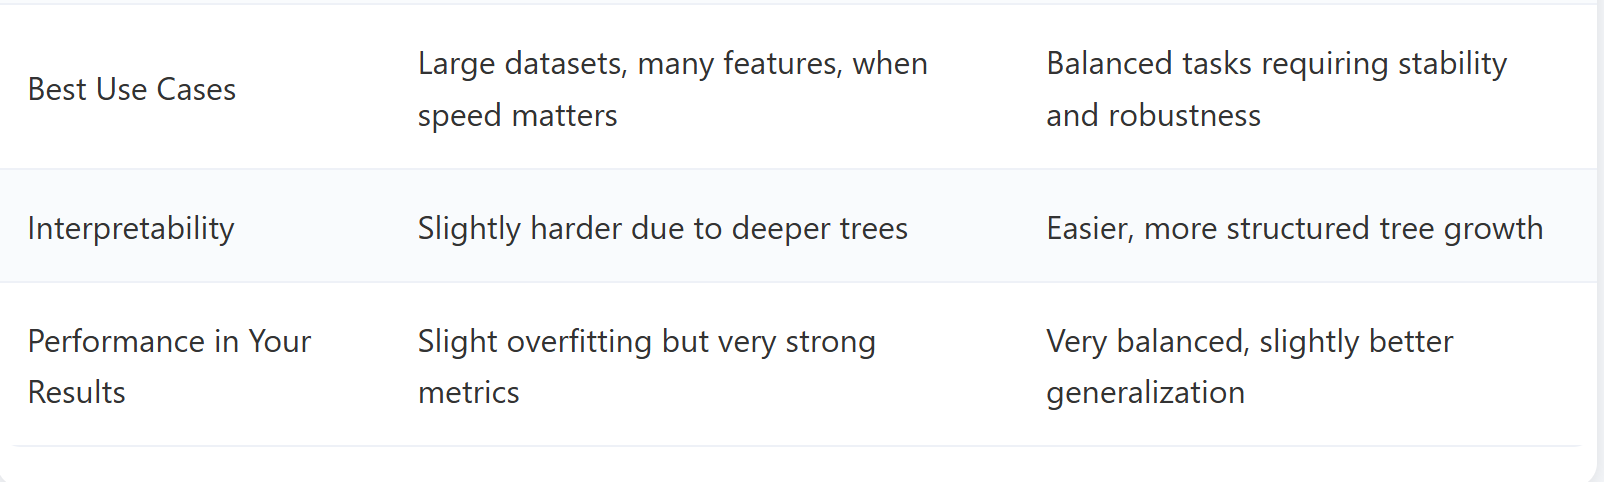

Observation:

Tuned LightGBM improves all metrics slightly but consistently.

Overfitting gap (Train vs Test) remains very small (~0.58%), acceptable for tree-based models.

In [ ]:

# ---------------------------
# 10) SHAP explainability
# ---------------------------
explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=final_features)

importances = pd.Series(final_lgb.feature_importances_, index=final_features).sort_values(ascending=False)
top3 = list(importances.index[:3])
for f in top3:
    shap.dependence_plot(f, shap_values, X_test_scaled, feature_names=final_features)

# ---------------------------
# 11) Save pipeline
# ---------------------------
joblib.dump({'model': final_lgb, 'scaler': scaler, 'features': final_features}, '/content/final_lgb_pipeline.pkl')
print("Saved pipeline to /content/final_lgb_pipeline.pkl")

# ---------------------------
# 12)  Folium map
# ---------------------------
X_all_scaled = pd.DataFrame(scaler.transform(X[final_features]), columns=final_features, index=X.index)
df['pred_prob'] = final_lgb.predict_proba(X_all_scaled)[:,1]
sample = df.sample(2000, random_state=42)

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')
for _, r in sample.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=3,
        fill=True,
        fill_opacity=0.7,
        popup=f"prob:{r['pred_prob']:.3f}",
        color=None,
        fill_color=plt.cm.viridis(r['pred_prob'])
    ).add_to(m)

m.save('/content/prediction_map.html')
print("Map saved to /content/prediction_map.html")


#SHAP  Plot First pic
*********
Purpose: Shows the overall importance of features and how they influence the model’s predictions.

Observations:

lon, lat, and dist_to_center are the most impactful features on the model’s output.

Points are colored by the feature value (pink = high, blue = low):

For example, higher lat or lon tends to increase the model prediction (positive SHAP values).

Lower values of dist_to_center have a strong positive impact, indicating areas closer to the center are more likely predicted positively.

Most other features have smaller SHAP values, showing moderate or minor contributions.

# SHAP Dependence Plot for (lon) seconde image
*********
Purpose: Shows how the SHAP value for lon changes with its actual value and how it interacts with another feature (here, lat as color).

Observations:

SHAP values for lon increase with higher longitude values.

The color gradient shows interaction: higher lat enhances the effect of lon.

Indicates that longitude and latitude together have a non-linear effect on the prediction.

#SHAP Dependence Plot for (lat) third image
***********
Purpose: Similar to the previous plot, but focuses on lat with dist_to_center as the interaction feature.

Observations:

Higher latitude tends to increase the prediction probability.

The effect is stronger for smaller dist_to_center (closer to the center).

Shows a clear spatial relationship: areas closer to the center and at higher latitudes are more likely to be classified positively.

# Folium Map
***********
Purpose:

Maps the predicted probabilities across geographic coordinates.

Uses CircleMarker colored by predicted probability.

Why we use it:

Visualizes spatial patterns in predictions.

Useful for identifying hotspots or clusters of high/low probability areas.

Makes the model output actionable for decision-making or urban planning (or whatever your dataset represents).

SHAP graphs → model explainability & feature impact

Feature importance → quick overview of top features

Folium map → spatial visualization of predictions

#References
***
LightGBM vs XGBOOST - Which algorithm is better

https://www.geeksforgeeks.org/machine-learning/lightgbm-vs-xgboost-which-algorithm-is-better/

Optuna

https://www.geeksforgeeks.org/machine-learning/optuna/

SHAP : A Comprehensive Guide to SHapley Additive exPlanations

https://www.geeksforgeeks.org/machine-learning/shap-a-comprehensive-guide-to-shapley-additive-explanations/

Dataset
https://github.com/ckyriakos/thesis_front_end/blob/master/data/Data%20After%20Selection%20and%20Preprocessing/chicago_final.csv